## Boston housing 波士頓房價分析預測

[Ref] https://pse.is/4x9yse

掛載雲端硬碟

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
folder="/content/drive/MyDrive/資料科學自學聖經/ch09" 

載入套件

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn import datasets
import seaborn as sns
%matplotlib inline

匯入波士頓房價資料集

In [43]:
# Scikit-Learn 套件已經取消波士頓房價資料集
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_boston.html
# from sklearn.datasets import load_boston
# boston_dataset = load_boston()

boston_dataset = pd.read_csv('/content/drive/MyDrive/資料科學自學聖經/ch09/BostonHousing.csv')
boston_dataset 

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


觀察資料集的keys

In [44]:
print(boston_dataset.keys())

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')


列印各欄位敘述統計

In [45]:
print(boston_dataset.describe())

             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio           b  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

預測的是房價，目標變數是MEDV，其餘欄位是特徵變數。
下一步把資料轉換成pd.DataFrame：

In [46]:
boston = pd.DataFrame(boston_dataset.values, columns=boston_dataset.columns)
#boston.head()
boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


資料前置處理:確認是否有缺失值

In [47]:
boston.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

資料探索(DATA EDA):以資料視覺來看一下細部資料之間的關係


MEDIV房價變數的分佈大致呈鐘型常態分佈：

<ipython-input-48-240deb1438d2>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(boston['medv'])


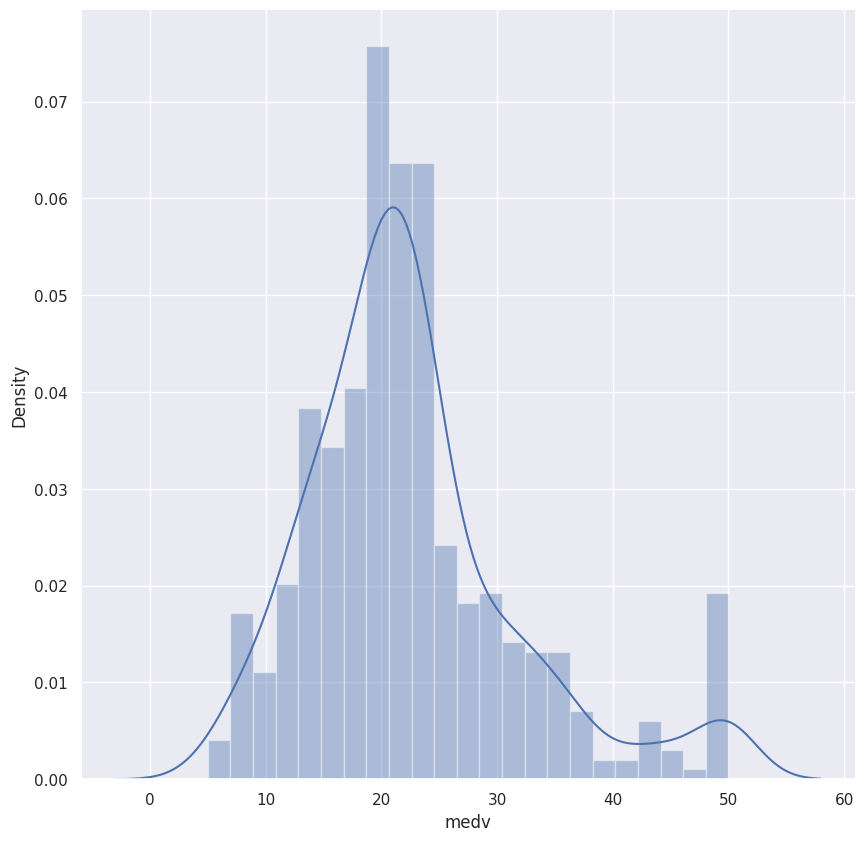

In [48]:
# 用seaborn一次把圖表的美化格式設定好，先設定圖表長寬
sns.set(rc={'figure.figsize':(10,10)})
# 使用的資料是房價medv
sns.distplot(boston['medv'])
plt.show()

相關分析:透過相關係數去觀察有哪些特徵變數和目標變數有較高的相關性,並以熱力圖呈現

<Axes: >

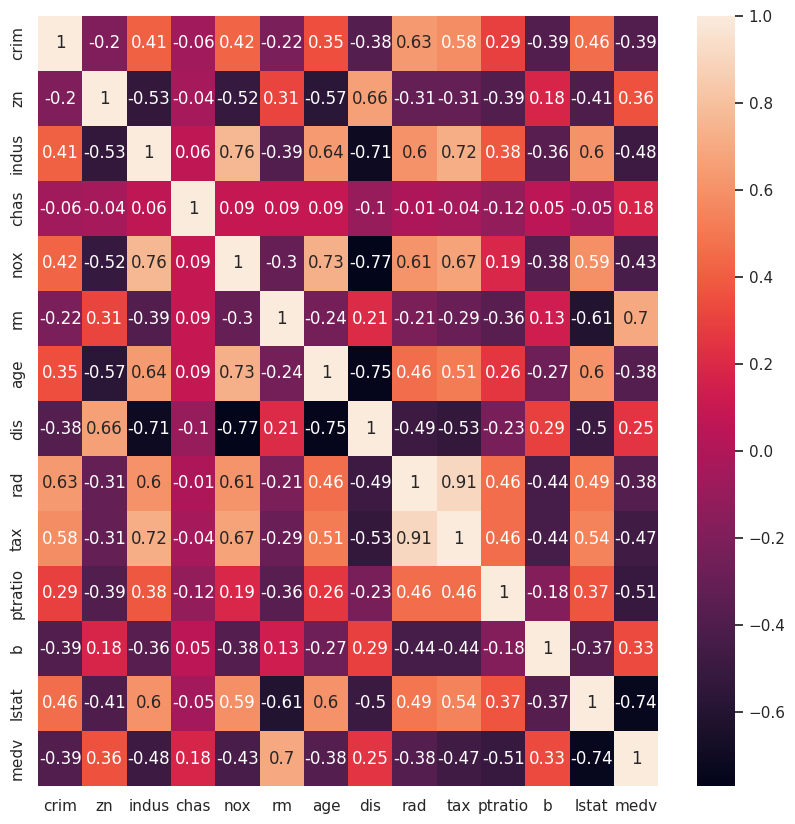

In [49]:
correlation_matrix = boston.corr().round(2)
# annot = True 可將數字標示在每個格子裡
sns.heatmap(data=correlation_matrix, annot = True)

根據熱力圖觀察,與MEDV（房價）高度相關的是LSTAT（中低收入戶佔當地居住人口的比例）和RM（房子有幾間房間）這兩個變數。可以用LSTAT和RM來做出預測MEDV的模型。


把這兩個變數跟房價變數的關係畫出來，可以看到兩者和房價變數都接近線性關係：

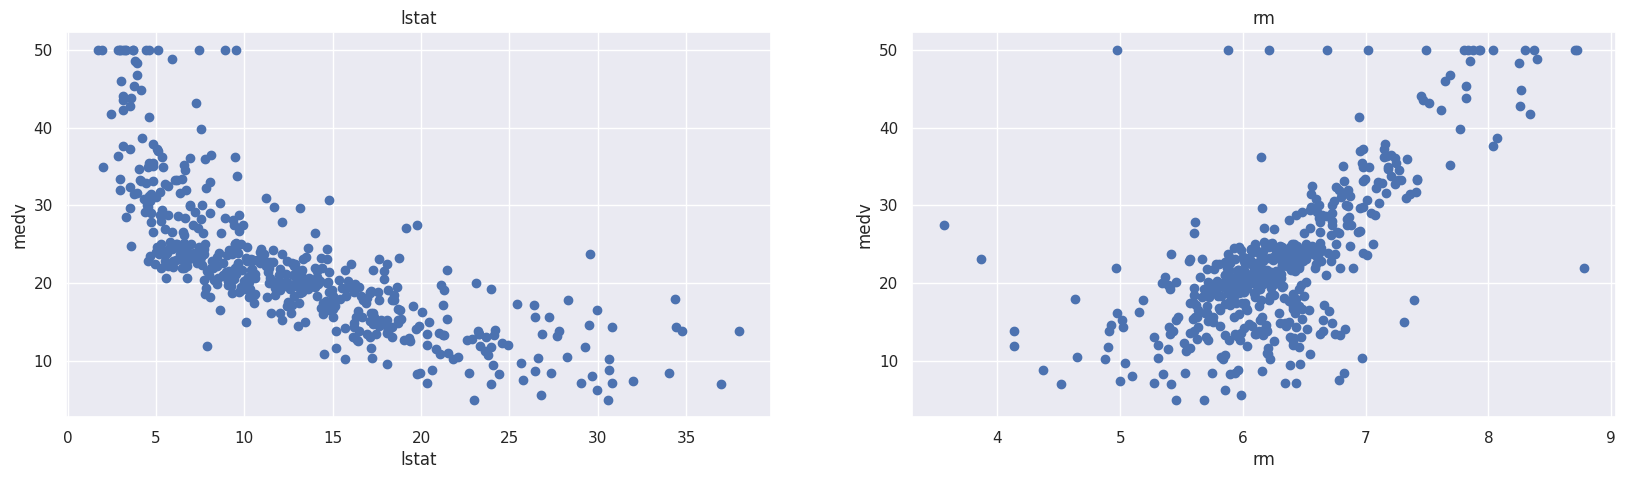

In [50]:
# 設定整張圖的長寬
plt.figure(figsize=(20, 5))
features = ['lstat', 'rm']
target = boston['medv']
for i, col in enumerate(features):
 # 排版1 row, 2 columns, nth plot：在jupyter notebook上兩張並排 
 plt.subplot(1, len(features) , i+1)
 # add data column into plot
 x = boston[col]
 y = target
 plt.scatter(x, y, marker='o')
 plt.title(col)
 plt.xlabel(col)
 plt.ylabel('medv')

準備模型的訓練資料:


用np.c_把LSTAT和RM兩個欄位合併在一起，assign成X，把MEDV欄位assign成Y：

In [51]:
X = pd.DataFrame(np.c_[boston['lstat'], boston['rm']], columns = ['lstat','rm'])
Y = boston['medv']

把資料切割成訓練training data（80%）和測試testing data（20%）：

In [52]:
# train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=5)
# 再用.shape看切出來的資料的長相（列, 欄）
print(X_train.shape) #(404, 2)
print(X_test.shape) #(102, 2)
print(Y_train.shape) #(404, )
print(Y_test.shape) #(102, )

(404, 2)
(102, 2)
(404,)
(102,)


產生模型:


new出一個LinearRegression的物件後，用特徵變數的訓練資料和目標變數的訓練資料產生一個模型。接著將特徵變數的測試資料倒進這個新產生的模型當中，得到預測的目標變數資料。最後將這個預測的目標變數資料（預測結果）和目標變數的測試資料（真實結果）做R2-score(R平方值)：

In [53]:
# Modeling
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
# 學習/訓練Fitting linear model
reg.fit(X_train,Y_train)
# 預測結果Predicting using the linear model
reg.predict(X_test)
# 真實結果：Y_test
# 測試準確度：
print('R2:' , reg.score(X_test, Y_test))

R2: 0.6628996975186952


將預測的目標變數資料和測試的目標變數資料畫成散佈圖

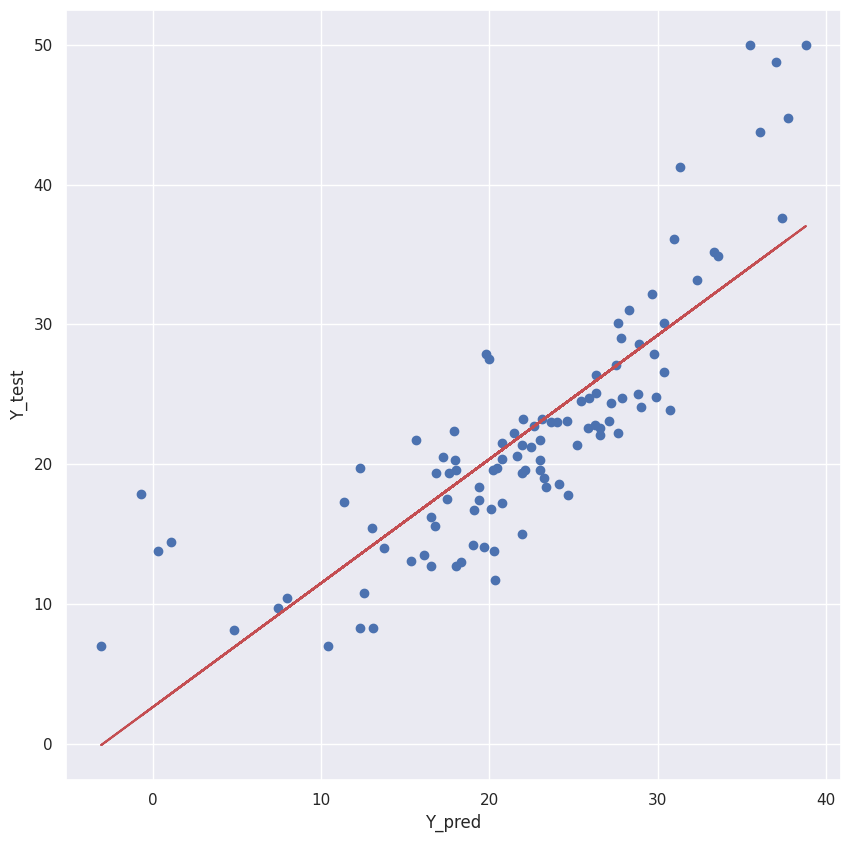

In [75]:
# plotting the y_test vs y_pred
Y_pred = reg.predict(X_test)
plt.scatter(Y_pred, Y_test)

# Calculate the Trendline
z = np.polyfit(Y_pred, Y_test, 1)
p = np.poly1d(z)

# Display the Trendline
plt.plot(Y_pred, p(Y_pred), 'r')


plt.xlabel('Y_pred')
plt.ylabel('Y_test')
plt.show()

印出模型的intercept(截距)和coefficient(係數)

In [55]:
#列印截距
reg.intercept_

2.73624034260661

In [56]:
#列印係數
coeff_df = pd.DataFrame(reg.coef_, X_train.columns, columns=['Coefficient'])  
coeff_df

,Coefficient
lstat,-0.717230
rm,4.589388


 Y  = X0  + a1X1+ a2X2 +b

 
MEDIV = 2.74 ＋ (-0.717230) * LSTAT + 4.589388 * RM + error

將Boston房價數據集中的房屋特徵數據轉換為NumPy數組

將每個房屋的房價轉換為NumPy數組，並列印數據集的前五行。

In [29]:
x = np.array(boston)
y = np.array(boston_dataset['medv'])[:, np.newaxis]
print(boston_dataset.head())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


定義正規方程式函式

In [30]:
#- Normal Equation
def normal_equation(data_x, data_y):
    #- Calculate the number of rows of data_x, labeled as m
    m = len(data_x)
    #- Add a spacer column to x
    x = np.c_[np.ones((m,1)), data_x]
    
    #- Theta = (xTx)^(-1)xTy 
    xTx = x.transpose().dot(x)
    theta = np.linalg.inv(xTx).dot(x.transpose()).dot(y)
    return theta


所得的Θ值(W:Weight)

In [31]:
#- Find theta using Normal Equation
theta_ne = normal_equation(x, y)
print('theta_ne ', theta_ne)

theta_ne  [[ 1.96369587e-11]
 [-4.18463007e-14]
 [ 7.49053597e-15]
 [ 1.48654526e-13]
 [-1.39111639e-12]
 [-3.38286066e-11]
 [-2.78554957e-13]
 [ 2.91793499e-14]
 [-7.53799800e-13]
 [ 8.07305611e-14]
 [ 1.35286747e-15]
 [-2.29274932e-13]
 [-1.94099294e-16]
 [ 7.38298311e-15]
 [ 1.00000000e+00]]
